# Emotion transition network explorer, VD-only version

This notebook looks for smooth affective paths between GoEmotions labels. It uses only **valence** and **dominance** for the affective transition geometry. Arousal is ignored. The smoothness measure is only `S`, the straightness ratio of the binned embedding path.


## Methodology

1. **Inputs.** Use GoEmotions single-label comment metadata and comment embeddings, usually produced by `goemotions_embed_pipeline.py`. The notebook expects `metadata.csv` and `embeddings.npy` or `embeddings.csv`.
2. **Affective coordinates.** Use the BRM/ANEW-style affect table as a lexicon, but keep only **valence** and **dominance**. Arousal is deliberately ignored in this notebook.
3. **Comment-level tone coordinate.** Each comment receives an approximate lexical VD vector by averaging valence and dominance scores of words in the comment that appear in the lexicon. If a comment has no covered words, it falls back to its emotion label's VD. This is noisy, but it gives a continuous tone axis instead of pretending each label is a tiny sealed jar.
4. **Transition axis.** For a source emotion `s` and target emotion `t`, define the line segment between their VD vectors. Every comment is projected onto that segment:
   - `tone_t = 0` means source-like,
   - `tone_t = 1` means target-like,
   - `tone_perp` is the affective VD distance away from the source-target transition corridor.
5. **Embedding movement.** For comments in the corridor, project their normalized embeddings onto the source-target embedding centroid vector and bin them along `tone_t`. This gives an empirical embedding path through the transition.
6. **Smoothness measure.** The notebook uses only `S` as the transition smoothness measure:

   \[
   S = \frac{\|p_K - p_1\|_2}{\sum_{k=1}^{K-1}\|p_{k+1}-p_k\|_2}.
   \]

   Here `p_k` is the normalized mean embedding of valid tone bin `k`. `S` is close to 1 when the binned embedding path is straight and decreases as the path bends. The older auxiliary diagnostics and combined ranking score are not used.
7. **Other diagnostics.** The table still reports `rho_t_embedding_projection`, the Spearman correlation between affective transition position and embedding projection, but it is not used as the smoothness score.
8. **Visuals.** The notebook builds a transition network over emotion labels in VD space, PCA plots of selected transitions, line plots showing how embedding position changes across tone bins, and an `S` heatmap whose source/target labels are ordered by valence.

Important caveat: this does **not** prove temporal emotional change inside a conversation. It measures whether independent comments arranged along a lexical affective gradient also move coherently through embedding space. Apparently nuance survives contact with linear algebra, sometimes.


## 0. Setup

Edit the paths in the next cell. The defaults try common locations in this project folder first.


In [1]:
from __future__ import annotations

import os
import re
import math
import json
import subprocess
from dataclasses import dataclass
from itertools import combinations
from pathlib import Path
from typing import Iterable, Sequence

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import spearmanr, pearsonr
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

SEED = 42
rng = np.random.default_rng(SEED)

# VD-only transition geometry. Keep this global so scan, focused transition, and plots cannot drift apart.
AFFECT_AXES = ["valence", "dominance"]
COMMENT_AFFECT_COLS = [f"comment_{axis}" for axis in AFFECT_AXES]
LABEL_AFFECT_COLS = [f"label_{axis}" for axis in AFFECT_AXES]
N_TONE_BINS = 12
MIN_BIN_COUNT = 5

# Candidate roots. Add your local GoEmotions directory here if needed.
ROOT_CANDIDATES = [
    Path.cwd(),
    Path("/mnt/data"),
    Path("D:/pyprojects/m4r/data/goemotions"),
    Path("./data/goemotions"),
]

GOEMOTIONS_LABELS = [
    "admiration", "amusement", "anger", "annoyance", "approval", "caring",
    "confusion", "curiosity", "desire", "disappointment", "disapproval",
    "disgust", "embarrassment", "excitement", "fear", "gratitude", "grief",
    "joy", "love", "nervousness", "optimism", "pride", "realization",
    "relief", "remorse", "sadness", "surprise", "neutral",
]

LABEL_WORD_FALLBACKS = {
    "caring": "care",
}


def first_existing(*paths: Path) -> Path | None:
    for path in paths:
        if path is not None and Path(path).exists():
            return Path(path)
    return None


def candidates(*relative_parts: str) -> list[Path]:
    return [root.joinpath(*relative_parts) for root in ROOT_CANDIDATES]

# Precomputed comment embeddings created by goemotions_embed_pipeline.py.
METADATA_PATH = first_existing(
    *candidates("manifold_outputs", "metadata.csv"),
    *candidates("metadata.csv"),
)
EMBEDDINGS_PATH = first_existing(
    *candidates("manifold_outputs", "embeddings.npy"),
    *candidates("manifold_outputs", "embeddings.csv"),
    *candidates("embeddings.npy"),
    *candidates("x_embd.csv"),
)

# Word-level affect file supplied in this project.
AFFECT_WORD_CSV = first_existing(
    *candidates("BRM-emot-submit.csv"),
    *candidates("emotion_label_vad_starter.csv"),
)

# GoEmotions raw data directory, only needed if you want to build embeddings from scratch.
DATA_DIR = first_existing(
    *[root for root in ROOT_CANDIDATES if (root / "train.tsv").exists()],
)

OUTPUT_DIR = Path("emotion_transition_outputs_vd")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("METADATA_PATH:", METADATA_PATH)
print("EMBEDDINGS_PATH:", EMBEDDINGS_PATH)
print("AFFECT_WORD_CSV:", AFFECT_WORD_CSV)
print("DATA_DIR:", DATA_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR.resolve())


METADATA_PATH: D:\pyprojects\m4r\data\goemotions\manifold_outputs\metadata.csv
EMBEDDINGS_PATH: D:\pyprojects\m4r\data\goemotions\manifold_outputs\embeddings.npy
AFFECT_WORD_CSV: D:\pyprojects\m4r\data\goemotions\BRM-emot-submit.csv
DATA_DIR: D:\pyprojects\m4r\data\goemotions
OUTPUT_DIR: D:\pyprojects\m4r\emotion_transition_outputs_vd


## 1. Optional: build embeddings if they do not exist

This cell wraps the existing embedding builder. Keep `RUN_EMBEDDING_BUILDER = False` unless you have `OPENAI_API_KEY` set and a local GoEmotions `train.tsv`. The builder keeps metadata aligned with embeddings, uses single-label comments, and can stratify sampling.


In [2]:
RUN_EMBEDDING_BUILDER = False
MAX_TOTAL = 5000
MAX_PER_LABEL = 250
EMBEDDING_MODEL = "text-embedding-3-large"

if RUN_EMBEDDING_BUILDER:
    script = first_existing(*candidates("goemotions_embed_pipeline.py"))
    if script is None:
        raise FileNotFoundError("Could not find goemotions_embed_pipeline.py. Put it in this folder or update ROOT_CANDIDATES.")
    if DATA_DIR is None:
        raise FileNotFoundError("Could not find a GoEmotions data directory containing train.tsv.")
    if not os.getenv("OPENAI_API_KEY"):
        raise EnvironmentError("OPENAI_API_KEY is not set. Do not paste keys into notebooks. The robots are already disappointed.")

    cmd = [
        "python", str(script),
        "--data-dir", str(DATA_DIR),
        "--max-total", str(MAX_TOTAL),
        "--max-per-label", str(MAX_PER_LABEL),
        "--model", EMBEDDING_MODEL,
        "--embed-label-words",
    ]
    print("Running:", " ".join(cmd))
    subprocess.run(cmd, check=True)

    METADATA_PATH = DATA_DIR / "manifold_outputs" / "metadata.csv"
    EMBEDDINGS_PATH = DATA_DIR / "manifold_outputs" / "embeddings.npy"
    print("Built:", METADATA_PATH, EMBEDDINGS_PATH)


## 2. Load embeddings, metadata, and the source affect lexicon

The source file may contain V, A, and D, but downstream transition geometry uses only V and D.


In [3]:
def load_embeddings(path: Path) -> np.ndarray:
    path = Path(path)
    if path.suffix.lower() == ".npy":
        return np.load(path)
    return pd.read_csv(path, header=None).to_numpy(dtype=np.float32)


def l2_normalize(X: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    X = np.asarray(X, dtype=np.float32)
    return X / np.maximum(np.linalg.norm(X, axis=1, keepdims=True), eps)


def require_file(path: Path | None, name: str) -> Path:
    if path is None or not Path(path).exists():
        raise FileNotFoundError(
            f"Missing {name}. Set the path in the setup cell or run the embedding builder. Missing value: {path}"
        )
    return Path(path)

metadata_path = require_file(METADATA_PATH, "metadata.csv")
embeddings_path = require_file(EMBEDDINGS_PATH, "embeddings.npy or embeddings.csv")
affect_word_path = require_file(AFFECT_WORD_CSV, "BRM/ANEW affect CSV")

metadata = pd.read_csv(metadata_path)
X_raw = load_embeddings(embeddings_path)
X = l2_normalize(X_raw)

if len(metadata) != len(X):
    raise ValueError(f"metadata rows ({len(metadata)}) != embedding rows ({len(X)}). Humanity has aligned fewer things than this, but still.")

print("metadata:", metadata.shape)
print("embeddings:", X.shape)
display(metadata.head())


metadata: (4997, 5)
embeddings: (4997, 3072)


,original_row,text,label_idx,label_name,embedding_text
0,6630,Your idea of what a nice entre or nice wine co...,0,admiration,Your idea of what a nice entre or nice wine co...
1,24661,I am so relieved,23,relief,I am so relieved
2,38794,A reason to play the game every 3 month?,7,curiosity,A reason to play the game every 3 month?
3,29718,Lakers truly have the worst fans,3,annoyance,Lakers truly have the worst fans
4,2871,Great way to clarify! That's the whole point o...,4,approval,Great way to clarify! That's the whole point o...


In [4]:
def load_word_vd(path: Path) -> pd.DataFrame:
    affect = pd.read_csv(path)
    # Support either BRM columns Word/V/D or normalized word/valence/dominance.
    rename = {}
    if "Word" in affect.columns:
        rename["Word"] = "word"
    if "V" in affect.columns:
        rename["V"] = "valence"
    elif "V.Mean.Sum" in affect.columns:
        rename["V.Mean.Sum"] = "valence"
    if "D" in affect.columns:
        rename["D"] = "dominance"
    elif "D.Mean.Sum" in affect.columns:
        rename["D.Mean.Sum"] = "dominance"
    if "label_name" in affect.columns and "word" not in affect.columns:
        rename["label_name"] = "word"
    affect = affect.rename(columns=rename).copy()
    required = {"word", "valence", "dominance"}
    missing = required - set(affect.columns)
    if missing:
        raise ValueError(f"Affect file missing columns needed for VD analysis: {sorted(missing)}")
    affect = affect[["word", "valence", "dominance"]].dropna().copy()
    affect["word"] = affect["word"].astype(str).str.lower().str.strip()
    for col in AFFECT_AXES:
        affect[col] = pd.to_numeric(affect[col], errors="coerce")
    affect = affect.dropna(subset=AFFECT_AXES)
    return affect.drop_duplicates("word")

word_vd = load_word_vd(affect_word_path)
word_vd_map = word_vd.set_index("word")[AFFECT_AXES]
print("word VD rows:", len(word_vd))
display(word_vd.head())


word VD rows: 13904


,word,valence,dominance
0,aardvark,6.26,4.27
1,abalone,5.30,4.95
2,abandon,2.84,3.32
3,abandonment,2.63,2.64
4,abbey,5.85,5.00


## 3. Build emotion-label VD coordinates


In [5]:
def make_label_vd(labels: Sequence[str], word_vd_map: pd.DataFrame, fallbacks: dict[str, str]) -> pd.DataFrame:
    rows = []
    missing = []
    for label in labels:
        lookup = fallbacks.get(label, label).lower()
        if lookup not in word_vd_map.index:
            missing.append((label, lookup))
            continue
        vals = word_vd_map.loc[lookup]
        rows.append({
            "label_name": label,
            "vd_lookup_word": lookup,
            "valence": float(vals["valence"]),
            "dominance": float(vals["dominance"]),
        })
    if missing:
        raise ValueError(f"Missing VD label words: {missing}")
    return pd.DataFrame(rows)

labels_present = [lab for lab in GOEMOTIONS_LABELS if lab in set(metadata["label_name"].astype(str))]
label_vd = make_label_vd(labels_present, word_vd_map, LABEL_WORD_FALLBACKS)
label_vd_path = OUTPUT_DIR / "emotion_label_vd_from_BRM.csv"
label_vd.to_csv(label_vd_path, index=False)
print("Saved label VD:", label_vd_path)
display(label_vd.sort_values("valence"))


Saved label VD: emotion_transition_outputs_vd\emotion_label_vd_from_BRM.csv


,label_name,vd_lookup_word,valence,dominance
16,grief,grief,2.33,3.26
25,sadness,sadness,2.40,3.84
2,anger,anger,2.50,5.14
12,embarrassment,embarrassment,2.72,2.92
9,disappointment,disappointment,2.79,4.08
14,fear,fear,2.93,3.32
3,annoyance,annoyance,2.95,3.45
19,nervousness,nervousness,3.10,3.93
6,confusion,confusion,3.32,3.08
11,disgust,disgust,3.32,4.84


## 4. Estimate comment-level lexical VD


In [6]:
WORD_RE = re.compile(r"[a-z]+(?:'[a-z]+)?")


def tokenize(text: object) -> list[str]:
    return WORD_RE.findall(str(text).lower())


def text_vd(text: object, word_vd_map: pd.DataFrame) -> tuple[float, float, int]:
    toks = tokenize(text)
    hits = [tok for tok in toks if tok in word_vd_map.index]
    if not hits:
        return (np.nan, np.nan, 0)
    arr = word_vd_map.loc[hits][AFFECT_AXES].to_numpy(dtype=float)
    vals = arr.mean(axis=0)
    return (float(vals[0]), float(vals[1]), len(hits))


def attach_vd_to_comments(metadata: pd.DataFrame, label_vd: pd.DataFrame, word_vd_map: pd.DataFrame) -> pd.DataFrame:
    out = metadata.copy().reset_index(drop=True)
    if "text" not in out.columns:
        raise ValueError("metadata must contain a 'text' column. The embedding builder writes this automatically.")
    lab = label_vd.rename(columns={
        "valence": "label_valence",
        "dominance": "label_dominance",
    })[["label_name", "label_valence", "label_dominance", "vd_lookup_word"]]
    out = out.merge(lab, on="label_name", how="left")
    if out[LABEL_AFFECT_COLS].isna().any().any():
        missing = sorted(out.loc[out["label_valence"].isna(), "label_name"].dropna().unique())
        raise ValueError(f"Missing label VD for labels: {missing}")

    vals = out["text"].map(lambda s: text_vd(s, word_vd_map))
    vd_arr = np.array(vals.tolist(), dtype=float)
    out["lex_valence"] = vd_arr[:, 0]
    out["lex_dominance"] = vd_arr[:, 1]
    out["lex_vd_n_words"] = vd_arr[:, 2].astype(int)

    # Fallback to label VD when the comment has no lexicon-covered words.
    for axis in AFFECT_AXES:
        out[f"comment_{axis}"] = out[f"lex_{axis}"].fillna(out[f"label_{axis}"])
    out["comment_vd_source"] = np.where(out["lex_vd_n_words"] > 0, "lexical_average", "label_fallback")
    return out

meta_vd = attach_vd_to_comments(metadata, label_vd, word_vd_map)
print(meta_vd["comment_vd_source"].value_counts(dropna=False))
print("Mean lexicon-covered VD words per comment:", meta_vd["lex_vd_n_words"].mean().round(2))
display(meta_vd[["text", "label_name", "comment_valence", "comment_dominance", "lex_vd_n_words", "comment_vd_source"]].head(10))


comment_vd_source
lexical_average    4848
label_fallback      149
Name: count, dtype: int64
Mean lexicon-covered VD words per comment: 4.08


,text,label_name,comment_valence,comment_dominance,lex_vd_n_words,comment_vd_source
0,Your idea of what a nice entre or nice wine co...,admiration,6.377143,5.862857,7,lexical_average
1,I am so relieved,relief,6.630000,5.640000,0,label_fallback
2,A reason to play the game every 3 month?,curiosity,6.597500,5.822500,4,lexical_average
3,Lakers truly have the worst fans,annoyance,5.860000,5.720000,1,lexical_average
4,Great way to clarify! That's the whole point o...,approval,6.288571,5.877143,7,lexical_average
5,I'm surprised everyone seems to think there wi...,surprise,6.292000,5.898000,5,lexical_average
6,I mean New Orleans is really fun even with lit...,admiration,6.390000,5.583333,6,lexical_average
7,Depends on the drug. Weed makes me antisocial ...,nervousness,5.105556,5.136667,9,lexical_average
8,You probably can. They're shit at hurling.,annoyance,5.160000,5.515000,2,lexical_average
9,"I'm terrible sorry, /u/bookluvr83, but I'm afr...",fear,3.975714,4.445714,7,lexical_average


## 5. Emotion centroids and transition geometry


In [7]:
def normalized_centroid(points: np.ndarray) -> np.ndarray:
    c = points.mean(axis=0)
    return c / max(np.linalg.norm(c), 1e-12)


def build_embedding_centroids(X: np.ndarray, meta: pd.DataFrame) -> dict[str, np.ndarray]:
    centroids = {}
    for label, group in meta.groupby("label_name", sort=True):
        idx = group.index.to_numpy()
        centroids[str(label)] = normalized_centroid(X[idx])
    return centroids

embedding_centroids = build_embedding_centroids(X, meta_vd)
label_vd_map = label_vd.set_index("label_name")[AFFECT_AXES]

centroid_summary = (
    meta_vd.groupby("label_name")
    .agg(
        n_comments=("label_name", "size"),
        mean_comment_valence=("comment_valence", "mean"),
        mean_comment_dominance=("comment_dominance", "mean"),
        lexical_coverage=("lex_vd_n_words", lambda s: float((s > 0).mean())),
    )
    .reset_index()
    .merge(label_vd, on="label_name", how="left")
)
display(centroid_summary.sort_values("n_comments", ascending=False))


,label_name,n_comments,mean_comment_valence,mean_comment_dominance,lexical_coverage,vd_lookup_word,valence,dominance
0,admiration,201,6.443734,5.933756,0.985075,admiration,7.58,6.11
1,amusement,201,5.932631,5.680784,0.940299,amusement,7.00,6.59
2,anger,201,5.021877,5.231483,0.985075,anger,2.50,5.14
3,annoyance,201,5.373612,5.394006,0.990050,annoyance,2.95,3.45
4,approval,201,5.979721,5.850101,0.955224,approval,6.75,6.63
5,caring,201,6.010351,5.723611,0.985075,care,7.64,6.56
6,confusion,201,5.551463,5.498511,0.975124,confusion,3.32,3.08
7,curiosity,201,5.715728,5.640843,0.925373,curiosity,6.37,6.21
8,desire,201,6.142922,5.772332,0.995025,desire,7.05,6.07
9,disappointment,201,5.245900,5.317779,0.965174,disappointment,2.79,4.08


In [8]:
def transition_coordinates(points: np.ndarray, source_point: np.ndarray, target_point: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """Project VD points onto the source-to-target VD segment.

    Returns
    -------
    tone_t : array
        Scalar projection. 0 means source endpoint, 1 means target endpoint.
    tone_perp : array
        Euclidean distance from each VD point to the infinite source-target line.
    """
    direction = target_point - source_point
    denom = float(np.dot(direction, direction))
    if denom < 1e-12:
        raise ValueError("Source and target VD endpoints are identical or too close.")
    centered = points - source_point[None, :]
    tone_t = centered @ direction / denom
    closest = source_point[None, :] + tone_t[:, None] * direction[None, :]
    tone_perp = np.linalg.norm(points - closest, axis=1)
    return tone_t, tone_perp


def embedding_transition_coordinates(X_points: np.ndarray, source_centroid: np.ndarray, target_centroid: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """Project embeddings onto the source-to-target embedding centroid vector."""
    direction = target_centroid - source_centroid
    denom = float(np.dot(direction, direction))
    if denom < 1e-12:
        raise ValueError("Source and target embedding centroids are identical or too close.")
    centered = X_points - source_centroid[None, :]
    emb_t = centered @ direction / denom
    closest = source_centroid[None, :] + emb_t[:, None] * direction[None, :]
    emb_perp = np.linalg.norm(X_points - closest, axis=1)
    return emb_t, emb_perp


def cosine_distance(a: np.ndarray, b: np.ndarray) -> float:
    a = a / max(np.linalg.norm(a), 1e-12)
    b = b / max(np.linalg.norm(b), 1e-12)
    return float(1.0 - np.clip(np.dot(a, b), -1.0, 1.0))


def safe_spearman(x: np.ndarray, y: np.ndarray) -> float:
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 3 or np.nanstd(x[mask]) == 0 or np.nanstd(y[mask]) == 0:
        return np.nan
    return float(spearmanr(x[mask], y[mask]).statistic)


def safe_pearson(x: np.ndarray, y: np.ndarray) -> float:
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 3 or np.nanstd(x[mask]) == 0 or np.nanstd(y[mask]) == 0:
        return np.nan
    return float(pearsonr(x[mask], y[mask]).statistic)


## 6. Analyze one emotion transition

The function below selects comments near the VD line from `source` to `target`, bins them by tone position, and computes `S`, the only smoothness measure used in this notebook.


In [9]:
def select_transition_corridor(
    meta: pd.DataFrame,
    X: np.ndarray,
    source: str,
    target: str,
    label_vd_map: pd.DataFrame,
    embedding_centroids: dict[str, np.ndarray],
    max_points: int = 1200,
    t_margin: float = 0.08,
    prefer_lexical_vd: bool = True,
    seed: int = SEED,
) -> dict:
    if source not in label_vd_map.index or target not in label_vd_map.index:
        raise ValueError(f"Unknown source/target labels: {source}, {target}")
    if source not in embedding_centroids or target not in embedding_centroids:
        raise ValueError(f"Missing source/target embedding centroids: {source}, {target}")

    affect_cols = COMMENT_AFFECT_COLS if prefer_lexical_vd else LABEL_AFFECT_COLS
    affect_points = meta[affect_cols].to_numpy(dtype=float)
    source_affect = label_vd_map.loc[source].to_numpy(dtype=float)
    target_affect = label_vd_map.loc[target].to_numpy(dtype=float)
    tone_t, tone_perp = transition_coordinates(affect_points, source_affect, target_affect)

    source_centroid = embedding_centroids[source]
    target_centroid = embedding_centroids[target]
    emb_t, emb_perp = embedding_transition_coordinates(X, source_centroid, target_centroid)

    scored = meta.copy().reset_index(drop=False).rename(columns={"index": "row_id"})
    scored["tone_t"] = tone_t
    scored["tone_perp"] = tone_perp
    scored["embedding_t"] = emb_t
    scored["embedding_perp"] = emb_perp

    # Keep points projected near the segment. Then take the nearest points to the VD transition line.
    in_band = scored["tone_t"].between(-t_margin, 1 + t_margin)
    pool = scored.loc[in_band].copy()
    if pool.empty:
        pool = scored.copy()

    # Encourage source/target examples to appear, but do not require them.
    pool["endpoint_bonus"] = np.where(pool["label_name"].isin([source, target]), -0.02, 0.0)
    pool["corridor_score"] = pool["tone_perp"] + pool["endpoint_bonus"]
    if len(pool) > max_points:
        pool = pool.sort_values("corridor_score", ascending=True).head(max_points)

    # Shuffle after selection to avoid plotting artifacts from sorted order.
    pool = pool.sample(frac=1.0, random_state=seed).reset_index(drop=True)
    idx = pool["row_id"].to_numpy(dtype=int)

    return {
        "source": source,
        "target": target,
        "points": pool,
        "X_points": X[idx],
        "source_affect": source_affect,
        "target_affect": target_affect,
        "source_centroid": source_centroid,
        "target_centroid": target_centroid,
    }


def binned_embedding_path(transition: dict, n_bins: int = N_TONE_BINS, min_bin_count: int = MIN_BIN_COUNT) -> pd.DataFrame:
    points = transition["points"].copy()
    X_points = transition["X_points"]
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    rows = []
    centroids = []

    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        if i == n_bins - 1:
            mask = points["tone_t"].between(lo, hi, inclusive="both").to_numpy()
        else:
            mask = ((points["tone_t"] >= lo) & (points["tone_t"] < hi)).to_numpy()
        n = int(mask.sum())
        if n < min_bin_count:
            continue
        c = normalized_centroid(X_points[mask])
        centroids.append(c)
        rows.append({
            "bin": i,
            "tone_t_center": (lo + hi) / 2,
            "n": n,
            "mean_tone_t": float(points.loc[mask, "tone_t"].mean()),
            "mean_tone_perp": float(points.loc[mask, "tone_perp"].mean()),
            "mean_embedding_t": float(points.loc[mask, "embedding_t"].mean()),
            "mean_embedding_perp": float(points.loc[mask, "embedding_perp"].mean()),
            "dominant_label": str(points.loc[mask, "label_name"].value_counts().idxmax()),
        })

    path = pd.DataFrame(rows)
    if len(path):
        path.attrs["centroids"] = np.vstack(centroids)
    else:
        path.attrs["centroids"] = np.empty((0, X_points.shape[1]))
    return path


def compute_S_from_path_centroids(C: np.ndarray) -> tuple[float, float, float]:
    """Return (S, direct_path_distance, path_length) for valid tone-bin centroids."""
    if len(C) < 2:
        return np.nan, np.nan, np.nan
    step_lengths = np.linalg.norm(np.diff(C, axis=0), axis=1)
    path_length = float(step_lengths.sum())
    direct_distance = float(np.linalg.norm(C[-1] - C[0]))
    S = float(direct_distance / path_length) if path_length > 1e-12 else np.nan
    return S, direct_distance, path_length


def summarize_transition(transition: dict, n_bins: int = N_TONE_BINS, min_bin_count: int = MIN_BIN_COUNT) -> tuple[dict, pd.DataFrame]:
    points = transition["points"]
    path = binned_embedding_path(transition, n_bins=n_bins, min_bin_count=min_bin_count)
    C = path.attrs["centroids"]

    source = transition["source"]
    target = transition["target"]
    src_c = transition["source_centroid"]
    tgt_c = transition["target_centroid"]

    S, direct_distance, path_length = compute_S_from_path_centroids(C)

    rho_t_embedding = safe_spearman(points["tone_t"].to_numpy(), points["embedding_t"].to_numpy())
    pearson_t_embedding = safe_pearson(points["tone_t"].to_numpy(), points["embedding_t"].to_numpy())
    rho_t_embedding_perp = safe_spearman(points["tone_t"].to_numpy(), points["embedding_perp"].to_numpy())

    vd_distance = float(np.linalg.norm(transition["target_affect"] - transition["source_affect"]))
    centroid_cosine_distance = cosine_distance(src_c, tgt_c)
    lexical_fraction = float((points["comment_vd_source"] == "lexical_average").mean()) if "comment_vd_source" in points else np.nan

    summary = {
        "source": source,
        "target": target,
        "n_points": int(len(points)),
        "n_labels": int(points["label_name"].nunique()),
        "n_bins": int(n_bins),
        "n_valid_bins": int(len(path)),
        "min_bin_count": int(min_bin_count),
        "vd_distance": vd_distance,
        "centroid_cosine_distance": centroid_cosine_distance,
        "rho_t_embedding_projection": rho_t_embedding,
        "pearson_t_embedding_projection": pearson_t_embedding,
        "rho_t_embedding_perp": rho_t_embedding_perp,
        "path_length": path_length,
        "direct_path_distance": direct_distance,
        "S": S,
        "lexical_vd_fraction": lexical_fraction,
    }
    return summary, path


def analyze_transition(
    source: str,
    target: str,
    n_bins: int = N_TONE_BINS,
    min_bin_count: int = MIN_BIN_COUNT,
    **corridor_kwargs,
) -> tuple[dict, pd.DataFrame, dict]:
    transition = select_transition_corridor(
        meta=meta_vd,
        X=X,
        source=source,
        target=target,
        label_vd_map=label_vd_map,
        embedding_centroids=embedding_centroids,
        **corridor_kwargs,
    )
    summary, path = summarize_transition(transition, n_bins=n_bins, min_bin_count=min_bin_count)
    return transition, path, summary


## 7. Scan all emotion pairs

This ranks transitions only by `S`, the straightness of the binned embedding path.


In [10]:
def scan_all_transitions(
    labels: Sequence[str],
    max_points: int = 1000,
    t_margin: float = 0.08,
    min_points: int = 80,
    n_bins: int = N_TONE_BINS,
    min_bin_count: int = MIN_BIN_COUNT,
) -> pd.DataFrame:
    rows = []
    for source, target in combinations(labels, 2):
        for s, t in [(source, target), (target, source)]:
            try:
                tr = select_transition_corridor(
                    meta=meta_vd,
                    X=X,
                    source=s,
                    target=t,
                    label_vd_map=label_vd_map,
                    embedding_centroids=embedding_centroids,
                    max_points=max_points,
                    t_margin=t_margin,
                )
                if len(tr["points"]) < min_points:
                    continue
                summary, _ = summarize_transition(tr, n_bins=n_bins, min_bin_count=min_bin_count)
                rows.append(summary)
            except Exception as exc:
                rows.append({"source": s, "target": t, "error": repr(exc)})
    results = pd.DataFrame(rows)
    if "S" in results.columns:
        results = results.sort_values("S", ascending=False).reset_index(drop=True)
    return results

transition_results = scan_all_transitions(labels_present, n_bins=N_TONE_BINS, min_bin_count=MIN_BIN_COUNT)
results_path = OUTPUT_DIR / "emotion_transition_metrics.csv"
transition_results.to_csv(results_path, index=False)
print("Saved transition metrics:", results_path)
display(transition_results.head(20))


Saved transition metrics: emotion_transition_outputs_vd\emotion_transition_metrics.csv


,source,target,n_points,n_labels,n_bins,n_valid_bins,min_bin_count,vd_distance,centroid_cosine_distance,rho_t_embedding_projection,pearson_t_embedding_projection,rho_t_embedding_perp,path_length,direct_path_distance,S,lexical_vd_fraction
0,embarrassment,pride,1000,28,12,7,5,4.770377,0.317987,0.373200,0.369826,0.086426,2.656400,0.820841,0.309005,0.996
1,pride,embarrassment,1000,28,12,7,5,4.770377,0.317987,0.373200,0.369826,-0.086425,2.656400,0.820841,0.309005,0.996
2,embarrassment,optimism,1000,28,12,9,5,6.000042,0.347300,0.303614,0.307892,0.069339,3.489448,0.940929,0.269650,0.982
3,optimism,embarrassment,1000,28,12,9,5,6.000042,0.347300,0.303614,0.307892,-0.069339,3.489448,0.940929,0.269650,0.982
4,curiosity,embarrassment,1000,28,12,8,5,4.913919,0.265572,0.302380,0.303893,-0.129402,3.060135,0.814153,0.266051,0.984
5,embarrassment,curiosity,1000,28,12,8,5,4.913919,0.265572,0.302380,0.303893,0.129402,3.060135,0.814153,0.266051,0.984
6,amusement,embarrassment,1000,28,12,9,5,5.638023,0.224260,0.344817,0.328729,-0.138520,3.607524,0.912983,0.253078,0.987
7,embarrassment,amusement,1000,28,12,9,5,5.638023,0.224260,0.344817,0.328729,0.138520,3.607524,0.912983,0.253078,0.987
8,gratitude,confusion,1000,28,12,9,5,4.939575,0.425092,0.186217,0.239506,0.107340,3.642990,0.895362,0.245777,0.993
9,confusion,gratitude,1000,28,12,9,5,4.939575,0.425092,0.186217,0.239506,-0.107340,3.642990,0.895362,0.245777,0.993


In [11]:
# Lowest-S transitions among ones that still move monotonically in the source-to-target embedding projection.
# This is a bendiness diagnostic, not an additional smoothness score.
if not transition_results.empty and {"S", "rho_t_embedding_projection"}.issubset(transition_results.columns):
    low_S_monotonic = transition_results.copy()
    low_S_monotonic = low_S_monotonic[
        np.isfinite(low_S_monotonic["S"]) &
        (low_S_monotonic["rho_t_embedding_projection"] > 0.25)
    ]
    low_S_monotonic = low_S_monotonic.sort_values("S", ascending=True)
    display(low_S_monotonic.head(20))


,source,target,n_points,n_labels,n_bins,n_valid_bins,min_bin_count,vd_distance,centroid_cosine_distance,rho_t_embedding_projection,pearson_t_embedding_projection,rho_t_embedding_perp,path_length,direct_path_distance,S,lexical_vd_fraction
695,nervousness,remorse,126,22,12,12,5,0.830963,0.371225,0.313869,0.325230,0.159757,9.843091,0.868056,0.088189,0.904762
694,remorse,nervousness,126,22,12,12,5,0.830963,0.371225,0.313869,0.325230,-0.159757,9.843091,0.868056,0.088189,0.904762
595,excitement,curiosity,1000,27,12,12,5,1.255747,0.269540,0.268950,0.262879,0.212208,5.006974,0.550848,0.110016,0.940000
594,curiosity,excitement,1000,27,12,12,5,1.255747,0.269540,0.268954,0.262879,-0.212210,5.006974,0.550848,0.110016,0.940000
551,fear,neutral,1000,28,12,12,5,3.578407,0.221943,0.287727,0.282573,0.196036,6.598640,0.763587,0.115719,0.988000
550,neutral,fear,1000,28,12,12,5,3.578407,0.221943,0.287725,0.282573,-0.196033,6.598640,0.763587,0.115719,0.988000
501,disappointment,realization,1000,28,12,12,5,3.966976,0.123821,0.289085,0.278381,0.169325,6.135337,0.747497,0.121835,0.990000
500,realization,disappointment,1000,28,12,12,5,3.966976,0.123821,0.289085,0.278381,-0.169325,6.135337,0.747497,0.121835,0.990000
495,love,excitement,200,25,12,8,5,0.559017,0.206582,0.407964,0.470604,0.168711,5.777379,0.715918,0.123917,0.900000
494,excitement,love,200,25,12,8,5,0.559017,0.206582,0.407964,0.470604,-0.168711,5.777378,0.715918,0.123917,0.900000


## 8. Plot the transition network

Nodes are emotion labels placed by valence and dominance. Edges are the highest-`S` transitions. This is a network picture, not a claim that your feelings use graph theory. They probably use worse infrastructure.


Saved: emotion_transition_outputs_vd\transition_network_valence_dominance.png


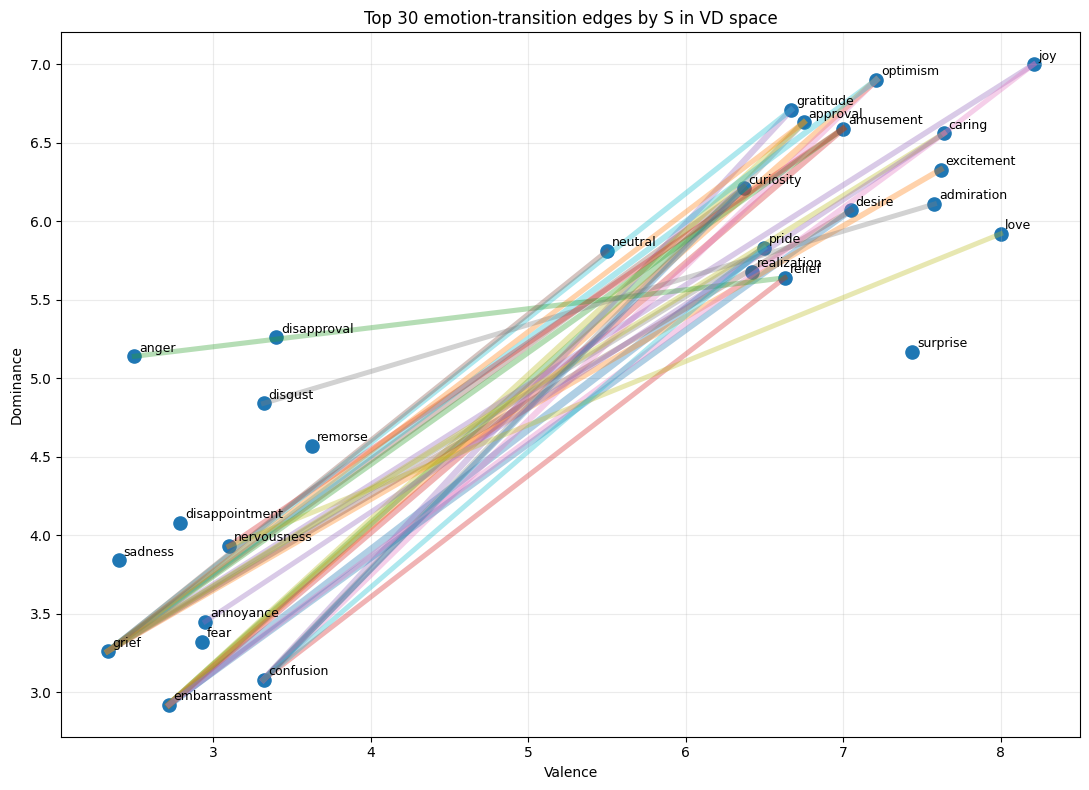

In [12]:
def plot_transition_network(
    results: pd.DataFrame,
    label_vd: pd.DataFrame,
    top_n: int = 30,
    min_S: float = 0.0,
    figsize: tuple[int, int] = (11, 8),
):
    if results.empty:
        raise ValueError("No transition results to plot.")
    coords = label_vd.set_index("label_name")[AFFECT_AXES]
    edges = results.dropna(subset=["S"]).query("S >= @min_S").copy()
    # Directed scans often contain both A->B and B->A. For a network view, keep one edge per unordered pair.
    edges["pair_key"] = edges.apply(lambda r: "--".join(sorted([str(r["source"]), str(r["target"])])), axis=1)
    edges = edges.sort_values("S", ascending=False).drop_duplicates("pair_key").head(top_n)

    fig, ax = plt.subplots(figsize=figsize)

    if len(edges):
        max_S = max(edges["S"].max(), 1e-12)
        for _, row in edges.iterrows():
            s, t = row["source"], row["target"]
            if s not in coords.index or t not in coords.index:
                continue
            xs = [coords.loc[s, "valence"], coords.loc[t, "valence"]]
            ys = [coords.loc[s, "dominance"], coords.loc[t, "dominance"]]
            lw = 0.5 + 5.0 * float(row["S"]) / max_S
            ax.plot(xs, ys, linewidth=lw, alpha=0.35)

    ax.scatter(coords["valence"], coords["dominance"], s=90)
    for label, row in coords.iterrows():
        ax.text(row["valence"] + 0.03, row["dominance"] + 0.03, label, fontsize=9)

    ax.set_xlabel("Valence")
    ax.set_ylabel("Dominance")
    ax.set_title(f"Top {len(edges)} emotion-transition edges by S in VD space")
    ax.grid(True, alpha=0.25)
    fig.tight_layout()
    out = OUTPUT_DIR / "transition_network_valence_dominance.png"
    fig.savefig(out, dpi=220)
    print("Saved:", out)
    return fig, ax

plot_transition_network(transition_results, label_vd, top_n=30)
plt.show()


## 9. Inspect a specific transition

Change `FOCUS_SOURCE` and `FOCUS_TARGET`. Good starting pairs are `joy -> sadness`, `approval -> disapproval`, `fear -> relief`, `anger -> gratitude`, and whichever pair the scan says is interesting.


In [13]:
FOCUS_SOURCE = "joy"
FOCUS_TARGET = "sadness"

focus_transition, focus_path, focus_summary = analyze_transition(
    FOCUS_SOURCE,
    FOCUS_TARGET,
    max_points=1400,
    t_margin=0.10,
    n_bins=N_TONE_BINS,
    min_bin_count=MIN_BIN_COUNT,
)

print(json.dumps(focus_summary, indent=2))
display(focus_path)

top_labels = focus_transition["points"]["label_name"].value_counts().head(12)
display(top_labels.rename("n_in_transition_corridor").to_frame())


{
  "source": "joy",
  "target": "sadness",
  "n_points": 1400,
  "n_labels": 28,
  "n_bins": 12,
  "n_valid_bins": 12,
  "min_bin_count": 5,
  "vd_distance": 6.613750826875775,
  "centroid_cosine_distance": 0.28057676553726196,
  "rho_t_embedding_projection": 0.5494991521197284,
  "pearson_t_embedding_projection": 0.5373319500895701,
  "rho_t_embedding_perp": 0.1262480899507693,
  "path_length": 5.375585556030273,
  "direct_path_distance": 0.856548011302948,
  "S": 0.15934041089571754,
  "lexical_vd_fraction": 0.9842857142857143
}


,bin,tone_t_center,n,mean_tone_t,mean_tone_perp,mean_embedding_t,mean_embedding_perp,dominant_label
0,0,0.041667,14,0.042403,0.044315,0.336143,1.052729,joy
1,1,0.125000,45,0.125675,0.052767,0.296063,1.069654,gratitude
2,2,0.208333,85,0.218437,0.059926,0.363444,1.077533,joy
3,3,0.291667,209,0.292965,0.052104,0.430112,1.100947,gratitude
4,4,0.375000,341,0.375140,0.054880,0.483052,1.121579,optimism
5,5,0.458333,302,0.458744,0.054323,0.547194,1.122776,optimism
6,6,0.541667,204,0.536090,0.054773,0.587940,1.115762,sadness
7,7,0.625000,96,0.620528,0.057140,0.617750,1.107530,fear
8,8,0.708333,46,0.703468,0.056520,0.605308,1.106061,sadness
9,9,0.791667,17,0.782744,0.053467,0.607537,1.082997,disgust


,n_in_transition_corridor
label_name,
joy,77
sadness,76
optimism,68
gratitude,68
caring,64
admiration,64
remorse,61
approval,61
desire,59


Saved: emotion_transition_outputs_vd\transition_pca_joy_to_sadness.png


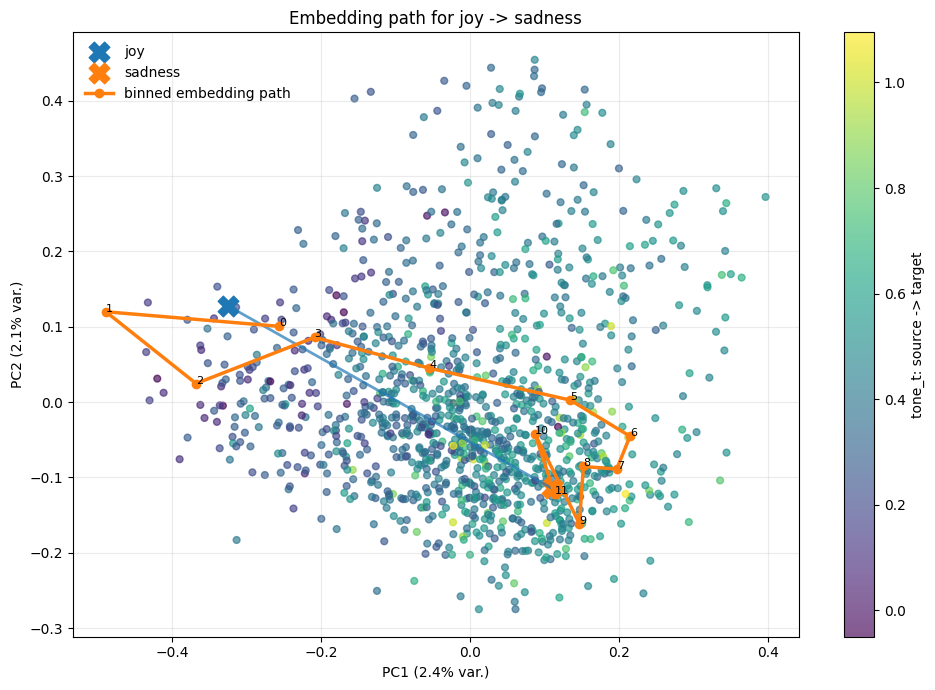

In [14]:
def plot_transition_pca(transition: dict, path: pd.DataFrame | None = None, sample_points: int = 1200):
    points = transition["points"].copy()
    X_points = transition["X_points"]
    if len(points) > sample_points:
        sampled = points.sample(n=sample_points, random_state=SEED).sort_index()
        X_plot = X_points[sampled.index.to_numpy()]
        points_plot = sampled.reset_index(drop=True)
    else:
        X_plot = X_points
        points_plot = points.reset_index(drop=True)

    extra = np.vstack([transition["source_centroid"], transition["target_centroid"]])
    fit_X = np.vstack([X_plot, extra])
    pca = PCA(n_components=2, random_state=SEED)
    Z = pca.fit_transform(fit_X)
    Z_points = Z[:len(X_plot)]
    Z_src, Z_tgt = Z[-2], Z[-1]

    fig, ax = plt.subplots(figsize=(10, 7))
    sc = ax.scatter(Z_points[:, 0], Z_points[:, 1], c=points_plot["tone_t"], s=24, alpha=0.65)
    fig.colorbar(sc, ax=ax, label="tone_t: source -> target")

    ax.scatter([Z_src[0]], [Z_src[1]], marker="X", s=220, label=transition["source"])
    ax.scatter([Z_tgt[0]], [Z_tgt[1]], marker="X", s=220, label=transition["target"])
    ax.plot([Z_src[0], Z_tgt[0]], [Z_src[1], Z_tgt[1]], linewidth=2, alpha=0.7)

    if path is not None and len(path):
        C = path.attrs["centroids"]
        C2 = pca.transform(C)
        ax.plot(C2[:, 0], C2[:, 1], marker="o", linewidth=2.5, label="binned embedding path")
        for i, row in path.reset_index(drop=True).iterrows():
            ax.text(C2[i, 0], C2[i, 1], str(int(row["bin"])), fontsize=8)

    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% var.)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% var.)")
    ax.set_title(f"Embedding path for {transition['source']} -> {transition['target']}")
    ax.legend(frameon=False)
    ax.grid(True, alpha=0.25)
    fig.tight_layout()
    out = OUTPUT_DIR / f"transition_pca_{transition['source']}_to_{transition['target']}.png"
    fig.savefig(out, dpi=220)
    print("Saved:", out)
    return fig, ax

plot_transition_pca(focus_transition, focus_path)
plt.show()


Saved: emotion_transition_outputs_vd\transition_projection_profile_joy_to_sadness.png


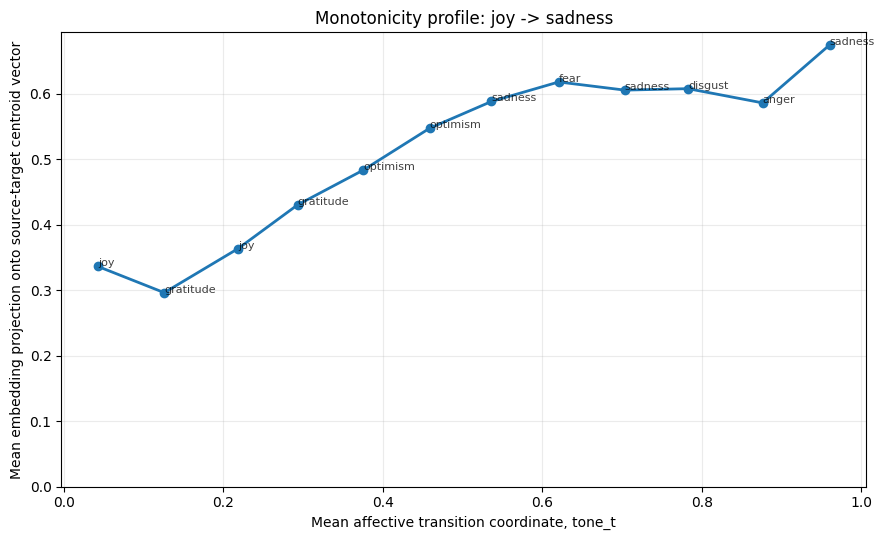

Saved: emotion_transition_outputs_vd\transition_step_lengths_joy_to_sadness.png


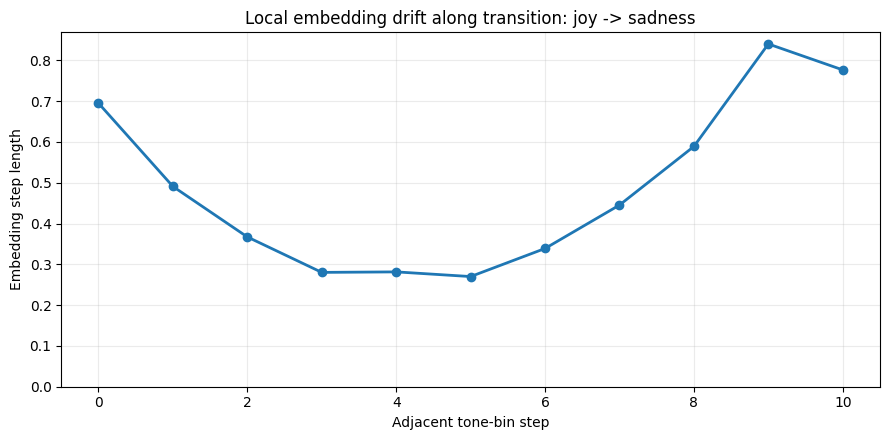

In [27]:
def plot_transition_profiles(path: pd.DataFrame, source: str, target: str):
    if path.empty:
        raise ValueError("No valid bins to plot.")

    fig, ax = plt.subplots(figsize=(9, 5.5))
    ax.plot(path["mean_tone_t"], path["mean_embedding_t"], marker="o", linewidth=2)
    for _, row in path.iterrows():
        ax.text(row["mean_tone_t"], row["mean_embedding_t"], str(row["dominant_label"]), fontsize=8, alpha=0.75)
    ax.set_xlabel("Mean affective transition coordinate, tone_t")
    ax.set_ylabel("Mean embedding projection onto source-target centroid vector")
    ax.set_ylim(bottom=0)
    ax.set_title(f"Monotonicity profile: {source} -> {target}")
    ax.grid(True, alpha=0.25)
    fig.tight_layout()
    out = OUTPUT_DIR / f"transition_projection_profile_{source}_to_{target}.png"
    fig.savefig(out, dpi=220)
    print("Saved:", out)
    plt.show()

    C = path.attrs.get("centroids")
    if C is not None and len(C) >= 2:
        step_lengths = np.linalg.norm(np.diff(C, axis=0), axis=1)
        fig, ax = plt.subplots(figsize=(9, 4.5))
        ax.plot(np.arange(len(step_lengths)), step_lengths, marker="o", linewidth=2)
        ax.set_xlabel("Adjacent tone-bin step")
        ax.set_ylabel("Embedding step length")
        ax.set_ylim(bottom=0)
        ax.set_title(f"Local embedding drift along transition: {source} -> {target}")
        ax.grid(True, alpha=0.25)
        fig.tight_layout()
        out = OUTPUT_DIR / f"transition_step_lengths_{source}_to_{target}.png"
        fig.savefig(out, dpi=220)
        print("Saved:", out)
        plt.show()

plot_transition_profiles(focus_path, FOCUS_SOURCE, FOCUS_TARGET)


## 10. Show example comments across the transition

This samples comments from early, middle, and late bins. It is the part where the embeddings have to face actual text, which is rude but necessary.


In [18]:
def sample_comments_across_transition(transition: dict, bins: Sequence[tuple[float, float]] | None = None, n_per_bin: int = 5) -> pd.DataFrame:
    points = transition["points"].copy()
    if bins is None:
        bins = [(0.00, 0.20), (0.40, 0.60), (0.80, 1.00)]
    rows = []
    for lo, hi in bins:
        chunk = points[points["tone_t"].between(lo, hi, inclusive="both")].copy()
        if chunk.empty:
            continue
        chunk = chunk.sort_values("tone_perp").head(max(n_per_bin * 5, n_per_bin))
        chunk = chunk.sample(n=min(n_per_bin, len(chunk)), random_state=SEED)
        chunk["tone_bin"] = f"{lo:.2f}-{hi:.2f}"
        rows.append(chunk[["tone_bin", "tone_t", "tone_perp", "embedding_t", "label_name", "text", "lex_vd_n_words", "comment_vd_source"]])
    if not rows:
        return pd.DataFrame()
    return pd.concat(rows, ignore_index=True).sort_values(["tone_bin", "tone_t"])

examples = sample_comments_across_transition(focus_transition, n_per_bin=6)
display(examples)
examples_path = OUTPUT_DIR / f"example_comments_{FOCUS_SOURCE}_to_{FOCUS_TARGET}.csv"
examples.to_csv(examples_path, index=False)
print("Saved:", examples_path)


,tone_bin,tone_t,tone_perp,embedding_t,label_name,text,lex_vd_n_words,comment_vd_source
1,0.00-0.20,0.083984,0.016632,0.267666,gratitude,thanks <3,1,lexical_average
3,0.00-0.20,0.083984,0.016632,0.299705,gratitude,"I haven't seen any of them, thanks!",1,lexical_average
4,0.00-0.20,0.083984,0.016632,0.241408,gratitude,thanks for answering!,1,lexical_average
5,0.00-0.20,0.083984,0.016632,0.335818,gratitude,"Alright, thanks again",1,lexical_average
2,0.00-0.20,0.106347,0.023461,0.265539,joy,Luckiest I’ve been is getting the toy I actual...,3,lexical_average
0,0.00-0.20,0.136283,0.031102,0.208377,excitement,All the game modes are super fun,3,lexical_average
7,0.40-0.60,0.404609,0.001633,0.563413,nervousness,"Yeah, Inbox didn't have those so I forgot all ...",1,lexical_average
6,0.40-0.60,0.415670,0.003583,0.570867,remorse,"Sorry, the two different names made me thing t...",6,lexical_average
9,0.40-0.60,0.416771,0.001640,0.637938,annoyance,The true horror of modern democracy is enablin...,9,lexical_average
8,0.40-0.60,0.492910,0.002737,0.687032,fear,Could you imagine? That would be so terrible f...,4,lexical_average


Saved: emotion_transition_outputs_vd\example_comments_joy_to_sadness.csv


## 11. Valence-ordered heatmap for transition smoothness


Labels ordered by valence:


,valence,dominance
label_name,,
grief,2.33,3.26
sadness,2.40,3.84
anger,2.50,5.14
embarrassment,2.72,2.92
disappointment,2.79,4.08
fear,2.93,3.32
annoyance,2.95,3.45
nervousness,3.10,3.93
confusion,3.32,3.08


Saved: emotion_transition_outputs_vd\heatmap_S_valence_ordered.png


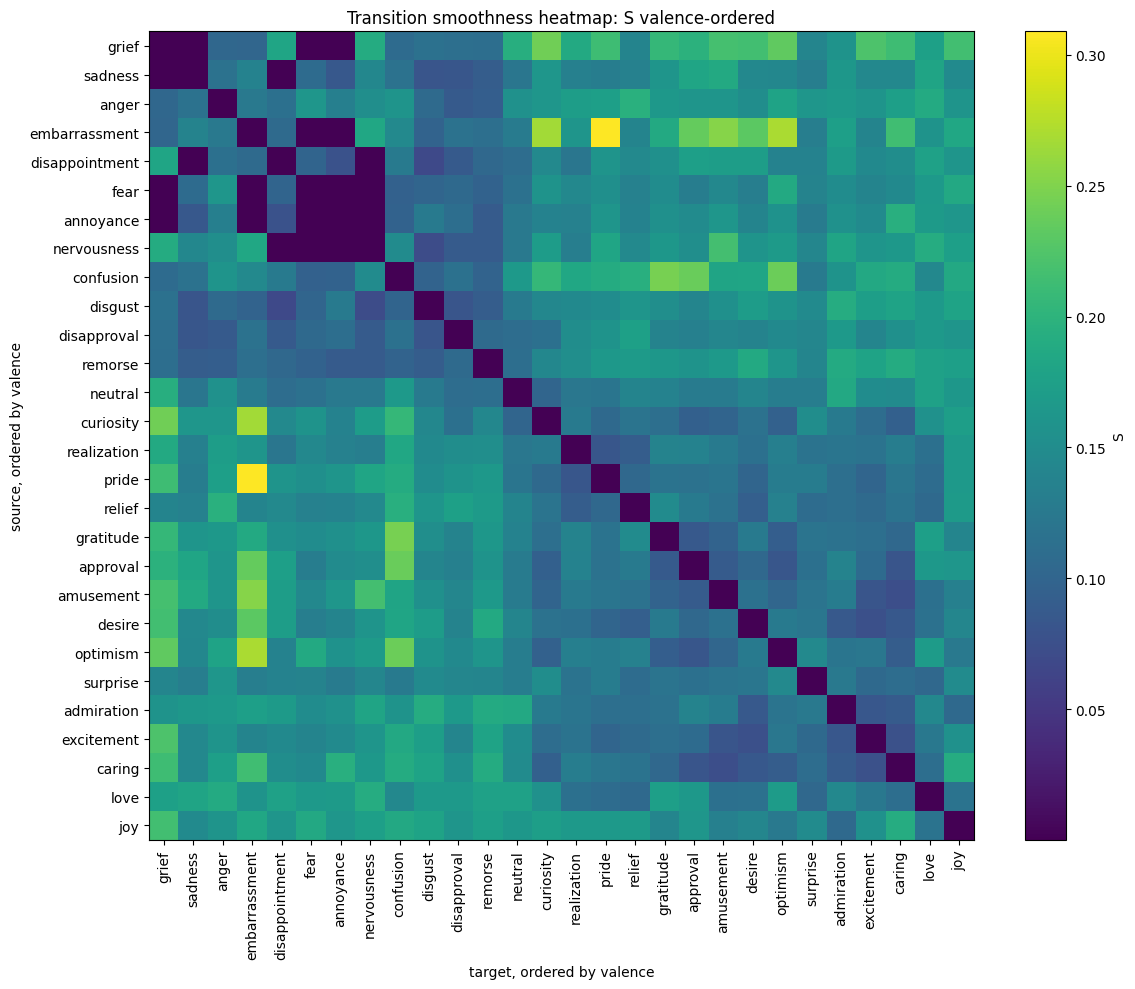

In [26]:
def metric_matrix(results: pd.DataFrame, metric: str, labels: Sequence[str]) -> pd.DataFrame:
    mat = pd.DataFrame(np.nan, index=labels, columns=labels, dtype=float)
    for _, row in results.dropna(subset=[metric]).iterrows():
        if row["source"] in mat.index and row["target"] in mat.columns:
            mat.loc[row["source"], row["target"]] = float(row[metric])
    return mat.fillna(1e-6)


def labels_ordered_by_valence(labels: Sequence[str], label_vd: pd.DataFrame, ascending: bool = True) -> list[str]:
    """Return labels sorted by their label-level valence coordinate."""
    order = (
        label_vd[label_vd["label_name"].isin(labels)]
        .sort_values(["valence", "label_name"], ascending=[ascending, True])
        ["label_name"]
        .tolist()
    )
    missing = [label for label in labels if label not in set(order)]
    return order + missing


def plot_metric_heatmap(
    results: pd.DataFrame,
    metric: str,
    labels: Sequence[str] | None = None,
    label_vd: pd.DataFrame | None = None,
    order_by_valence: bool = False,
):
    if labels is None:
        labels = sorted(set(results["source"]).union(set(results["target"])))
    labels = list(labels)
    if order_by_valence:
        if label_vd is None:
            raise ValueError("Pass label_vd when order_by_valence=True.")
        labels = labels_ordered_by_valence(labels, label_vd, ascending=True)

    mat = metric_matrix(results, metric, labels)

    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(mat.to_numpy(), aspect="auto")
    fig.colorbar(im, ax=ax, label=metric)
    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, rotation=90)
    ax.set_yticklabels(labels)
    ax.set_xlabel("target, ordered by valence")
    ax.set_ylabel("source, ordered by valence")
    suffix = " valence-ordered" if order_by_valence else ""
    ax.set_title(f"Transition smoothness heatmap: {metric}{suffix}")
    fig.tight_layout()
    out_name = f"heatmap_{metric}"
    if order_by_valence:
        out_name += "_valence_ordered"
    out = OUTPUT_DIR / f"{out_name}.png"
    fig.savefig(out, dpi=220)
    print("Saved:", out)
    return fig, ax


labels_by_valence = labels_ordered_by_valence(labels_present, label_vd, ascending=True)
print("Labels ordered by valence:")
display(label_vd.set_index("label_name").loc[labels_by_valence, AFFECT_AXES])

plot_metric_heatmap(
    transition_results,
    "S",
    labels=labels_present,
    label_vd=label_vd,
    order_by_valence=True,
)
plt.show()


## 12. Interpretation guide

Use the table and plots like this:

- **High `S`:** the binned embedding path is close to a straight line between its first and last valid tone-bin centroids.
- **Low `S`:** the embedding path bends or detours through intermediate regions of the representation space.
- **`n_bins` vs `n_valid_bins`:** `n_bins` is the requested number of tone bins, fixed at `N_TONE_BINS = 12` by default. `n_valid_bins` is the number that survive the `MIN_BIN_COUNT` filter. If `n_valid_bins < n_bins`, the plotted path skips sparse bins instead of inventing centroids from too few comments.
- **High `rho_t_embedding_projection`:** comments that are more target-like in VD affect also tend to project farther along the source-to-target embedding axis. This is useful context, but it is not part of the smoothness score.
- **Low or negative `rho_t_embedding_projection`:** lexical VD changes do not align with the source-target embedding axis. Either the pair is not a meaningful gradual transition, the VD approximation is weak, or the embedding is capturing pragmatic/contextual information rather than affect alone. Human language, tragically, contains context.
- **Low `lexical_vd_fraction`:** many comments fell back to label-level VD; treat that transition as label-driven rather than text-driven.

Suggested robustness checks:

1. Compare lexical comment VD with label-only VD by setting `prefer_lexical_vd=False` inside `select_transition_corridor`.
2. Increase `MAX_TOTAL` in the embedding builder to reduce sparse-bin artifacts.
3. Re-run with multiple embedding models.
4. Repeat the scan with `max_points`, `t_margin`, `n_bins`, and `min_bin_count` varied.
5. Inspect sampled comments, because numbers without examples are how spreadsheets develop delusions of grandeur.


## 13. Export compact report tables


In [20]:
report_cols = [
    "source", "target", "S", "rho_t_embedding_projection", "pearson_t_embedding_projection",
    "rho_t_embedding_perp", "n_points", "n_labels", "n_bins", "n_valid_bins", "min_bin_count",
    "path_length", "direct_path_distance", "vd_distance", "centroid_cosine_distance", "lexical_vd_fraction",
]

compact = transition_results[[c for c in report_cols if c in transition_results.columns]].copy()
compact_path = OUTPUT_DIR / "emotion_transition_compact_report.csv"
compact.to_csv(compact_path, index=False)
print("Saved:", compact_path)
display(compact.head(30))


Saved: emotion_transition_outputs_vd\emotion_transition_compact_report.csv


,source,target,S,rho_t_embedding_projection,pearson_t_embedding_projection,rho_t_embedding_perp,n_points,n_labels,n_bins,n_valid_bins,min_bin_count,path_length,direct_path_distance,vd_distance,centroid_cosine_distance,lexical_vd_fraction
0,embarrassment,pride,0.309005,0.373200,0.369826,0.086426,1000,28,12,7,5,2.656400,0.820841,4.770377,0.317987,0.996
1,pride,embarrassment,0.309005,0.373200,0.369826,-0.086425,1000,28,12,7,5,2.656400,0.820841,4.770377,0.317987,0.996
2,embarrassment,optimism,0.269650,0.303614,0.307892,0.069339,1000,28,12,9,5,3.489448,0.940929,6.000042,0.347300,0.982
3,optimism,embarrassment,0.269650,0.303614,0.307892,-0.069339,1000,28,12,9,5,3.489448,0.940929,6.000042,0.347300,0.982
4,curiosity,embarrassment,0.266051,0.302380,0.303893,-0.129402,1000,28,12,8,5,3.060135,0.814153,4.913919,0.265572,0.984
5,embarrassment,curiosity,0.266051,0.302380,0.303893,0.129402,1000,28,12,8,5,3.060135,0.814153,4.913919,0.265572,0.984
6,amusement,embarrassment,0.253078,0.344817,0.328729,-0.138520,1000,28,12,9,5,3.607524,0.912983,5.638023,0.224260,0.987
7,embarrassment,amusement,0.253078,0.344817,0.328729,0.138520,1000,28,12,9,5,3.607524,0.912983,5.638023,0.224260,0.987
8,gratitude,confusion,0.245777,0.186217,0.239506,0.107340,1000,28,12,9,5,3.642990,0.895362,4.939575,0.425092,0.993
9,confusion,gratitude,0.245777,0.186217,0.239506,-0.107340,1000,28,12,9,5,3.642990,0.895362,4.939575,0.425092,0.993


## 14. Optional: compare transition scores with centroid-level manifold alignment

If you also ran `goemotions_manifold_analysis.py`, you can compare these transition-level results to the global centroid-level alignment results. The two analyses answer different questions:

- centroid-level manifold alignment asks whether distances among emotion labels resemble affective distances overall;
- this notebook asks whether **ordered local paths** between two emotion endpoints are smooth in embedding space.


In [21]:
MANIFOLD_RESULTS_PATH = first_existing(
    *candidates("manifold_outputs", "analysis", "distance_alignment_results.csv"),
    *candidates("distance_alignment_results.csv"),
)

if MANIFOLD_RESULTS_PATH is not None:
    manifold_results = pd.read_csv(MANIFOLD_RESULTS_PATH)
    display(manifold_results.sort_values("spearman_rho", key=lambda s: s.abs(), ascending=False).head(20))
else:
    print("No manifold distance_alignment_results.csv found. This comparison is optional, not a moral failing. Probably.")


,level,n_points,representation,pca_dim_requested,explained_variance,distance_method,knn_k,graph_connected_components,ground_truth_space,permutation_p_abs_spearman,pearson_r,pearson_p,spearman_rho,spearman_p,kendall_tau,kendall_p,n_pairs
53,comment_centroid,28,pca_10,10,0.766721,knn_geodesic_angular,3.0,1.0,valence,0.009901,0.695096,7.621937e-56,0.679765,1.429365e-52,0.464721,2.095630e-41,378
66,comment_centroid,28,pca_25,25,0.992096,knn_geodesic_angular,2.0,1.0,VAD,0.009901,0.694175,1.214858e-55,0.674093,2.071191e-51,0.475011,2.982520e-43,378
20,comment_centroid,28,pca_2,2,0.303420,direct_angular,NaN,NaN,valence,0.009901,0.680243,1.138244e-52,0.666855,5.759145e-50,0.463232,3.759068e-41,378
17,comment_centroid,28,pca_2,2,0.303420,direct_cosine,NaN,NaN,valence,0.009901,0.687462,3.445160e-54,0.666855,5.759145e-50,0.463232,3.759068e-41,378
23,comment_centroid,28,pca_2,2,0.303420,knn_geodesic_angular,3.0,1.0,valence,0.009901,0.680243,1.138104e-52,0.666855,5.759145e-50,0.463232,3.759068e-41,378
29,comment_centroid,28,pca_2,2,0.303420,knn_geodesic_angular,10.0,1.0,valence,0.009901,0.680243,1.138089e-52,0.666855,5.759145e-50,0.463232,3.759068e-41,378
26,comment_centroid,28,pca_2,2,0.303420,knn_geodesic_angular,5.0,1.0,valence,0.009901,0.680243,1.138089e-52,0.666855,5.759145e-50,0.463232,3.759068e-41,378
68,comment_centroid,28,pca_25,25,0.992096,knn_geodesic_angular,2.0,1.0,valence,0.009901,0.691429,4.826175e-55,0.666773,5.977933e-50,0.459748,1.464362e-40,378
24,comment_centroid,28,pca_2,2,0.303420,knn_geodesic_angular,5.0,1.0,VAD,0.009901,0.677115,5.022964e-52,0.665883,8.939789e-50,0.471109,1.424215e-42,378
21,comment_centroid,28,pca_2,2,0.303420,knn_geodesic_angular,3.0,1.0,VAD,0.009901,0.677115,5.023012e-52,0.665883,8.939789e-50,0.471109,1.424215e-42,378
